# Difference-in-Differences

ref.

https://theeffectbook.net/ch-DifferenceinDifference.html 

In [2]:
source("src/functions_and_things.r")

load_libraries()

In [21]:
df_daily <- read.csv("data/daily_ridership.csv")
head(df_daily)

,date,borough,ridership
,<chr>,<chr>,<int>
1,2024-06-03,Bronx,81362
2,2024-06-03,Brooklyn,262036
3,2024-06-03,Manhattan,316780
4,2024-06-03,Queens,174702
5,2024-06-04,Bronx,84976
6,2024-06-04,Brooklyn,284948


In [41]:
df_ma <- read.csv("data/smooth.csv")
head(df_ma)

,week,borough,ridership
,<chr>,<chr>,<int>
1,2024-06-02,Bronx,412577
2,2024-06-02,Brooklyn,1341978
3,2024-06-02,Manhattan,1617170
4,2024-06-02,Queens,878117
5,2024-06-09,Bronx,415838
6,2024-06-09,Brooklyn,1327719


In [32]:
df_weekly <- read.csv("data/combined_data_weekly.csv")

df_weekly$week <- as.Date(df_weekly$week)

head(df_weekly)

,week,borough,ridership
,<date>,<chr>,<int>
1,2024-06-02,Bronx,412577
2,2024-06-02,Brooklyn,1341978
3,2024-06-02,Manhattan,1617170
4,2024-06-02,Queens,878117
5,2024-06-09,Bronx,415838
6,2024-06-09,Brooklyn,1327719


## Differince in Diff - effect book

### 18.2.1 - two way fixed effects

$$Y = \alpha_g + \alpha_t + \beta_1\text{Treated} + \epsilon$$

where 

$$
\begin{align*}
    Y &= ridership \\
    \alpha_g &= \text{treated or untreated}  \\
    \alpha_t &= \text{time period (treatment or not, post 2025)} \\
    \text{Treated} &= \text{binary variable, 1 if Manhattan after 2025}
\end{align*}
$$

"Two way fixed effects difference in differences estimator"

In [42]:
# treatment variable
df_daily |>
    mutate(
        date    = as.Date(date),
        Treated = (borough == "Manhattan") & (date > "2025-01-01")) -> df_daily

In [51]:
df_daily |> filter(borough == "Manhattan" | borough == "Brooklyn") -> df_daily_group

tail(df_daily_group)

,date,borough,ridership,Treated
,<date>,<chr>,<int>,<lgl>
819,2025-12-26,Brooklyn,172166,FALSE
820,2025-12-26,Manhattan,198798,TRUE
821,2025-12-29,Brooklyn,223939,FALSE
822,2025-12-29,Manhattan,247649,TRUE
823,2025-12-30,Brooklyn,235335,FALSE
824,2025-12-30,Manhattan,257374,TRUE


In [49]:
check <- (df_daily$borough == "Manhattan" & df_daily$Treated == "FALSE")
sum(check)

[1] 153

In [52]:
# foels 
clfe <- feols(ridership ~ Treated | borough + date, data = df_daily_group)

msummary(clfe, stars = c('*' = .1, '**' = .05, '***' = .01))


+----------------+---------------+
|                | (1)           |
+================+===============+
| TreatedTRUE    | -26913.889*** |
+----------------+---------------+
|                | (1282.324)    |
+----------------+---------------+
| Num.Obs.       | 824           |
+----------------+---------------+
| R2             | 0.996         |
+----------------+---------------+
| R2 Adj.        | 0.993         |
+----------------+---------------+
| R2 Within      | 0.518         |
+----------------+---------------+
| R2 Within Adj. | 0.517         |
+----------------+---------------+
| AIC            | 17576.5       |
+----------------+---------------+
| BIC            | 19528.1       |
+----------------+---------------+
| RMSE           | 6272.75       |
+----------------+---------------+
| FE: borough    | X             |
+----------------+---------------+
| FE: date       | X             |
+================+===============+
| * p < 0.1, ** p < 0.05, *** p  |
| < 0.01           

`geom_smooth()` using formula = 'y ~ x'


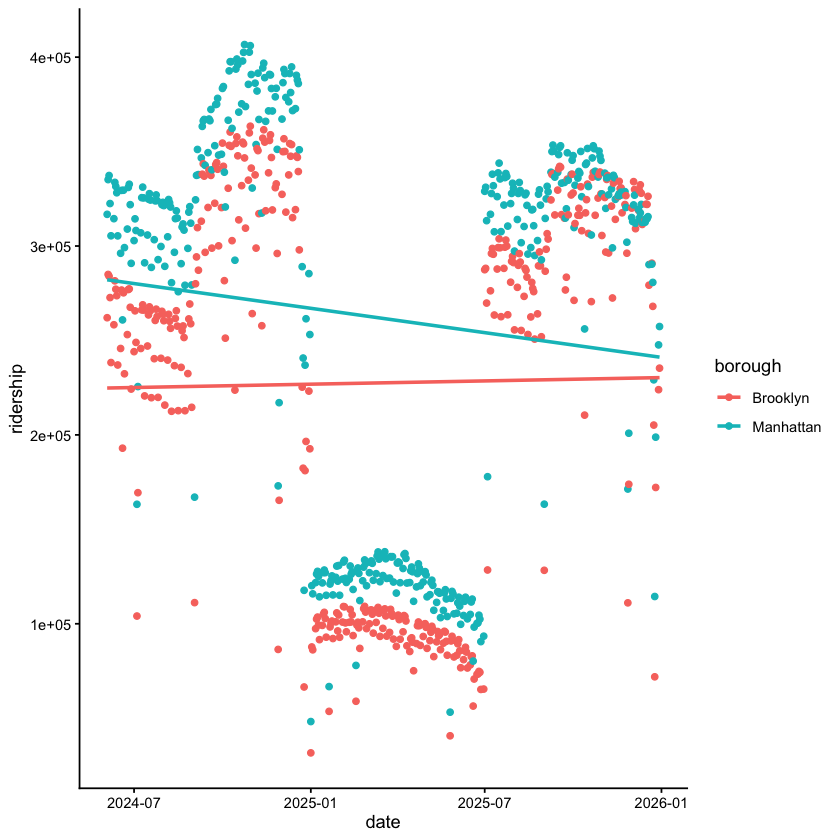

In [53]:
ggplot(data = df_daily_group, aes(x = date, y = ridership, color = borough)) + 
    geom_point() + theme_classic() + geom_smooth(method = "lm", se = FALSE)

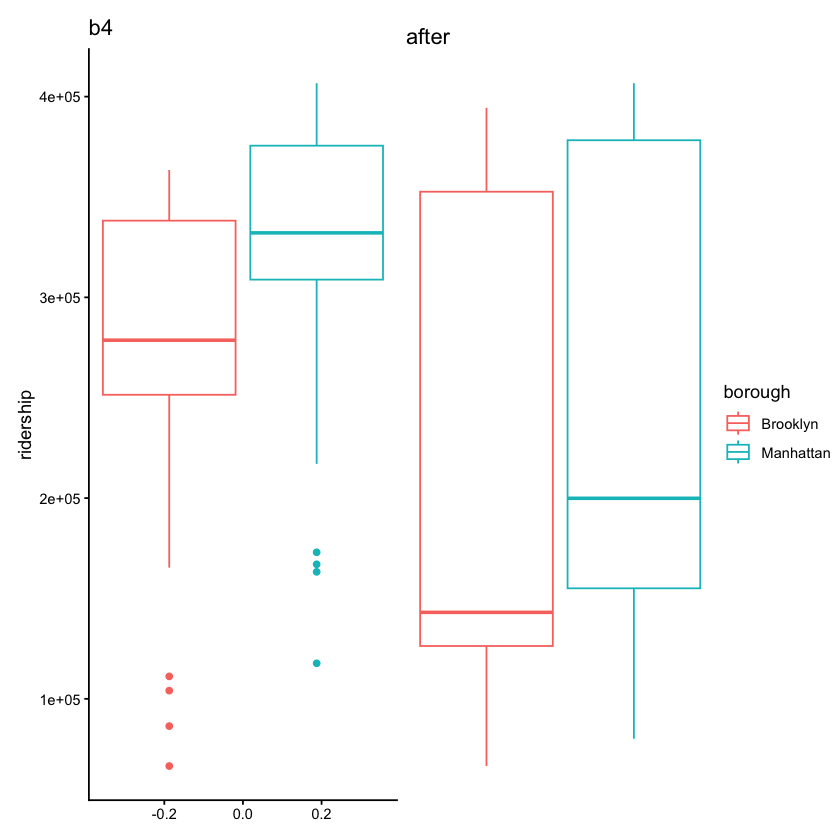

In [54]:
df_daily_group |> filter(date < "2025-01-01") |> 
ggplot(aes(y = ridership, color = borough)) + 
    geom_boxplot() + theme_classic() +
    theme(legend.position = "none") + labs(title = "b4")-> before

df_daily_group |> filter(date > "2025-01-01") |> 
ggplot(aes(y = ridership, color = borough)) + 
    geom_boxplot() + theme_void() + 
    labs(title = "after") -> after

before + after

### 18.2.3 supporting parallel trends?


$$Y = \alpha_g + \beta_1 Time + \beta_2 Time * Group + \epsilon$$

Are the trends different?

In [56]:
p_reg <- lm(ridership ~ date + date:borough, data = df_daily_group)
summary(p_reg)


Call:
lm(formula = ridership ~ date + date:borough, data = df_daily_group)

Residuals:
    Min      1Q  Median      3Q     Max 
-215657 -128072   43002   83897  140721 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)            8.660e+05  4.341e+05   1.995   0.0464 *  
date                  -3.166e+01  2.153e+01  -1.471   0.1418    
date:boroughManhattan  1.687e+00  3.555e-01   4.745 2.46e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 102900 on 821 degrees of freedom
Multiple R-squared:  0.02905,	Adjusted R-squared:  0.02668 
F-statistic: 12.28 on 2 and 821 DF,  p-value: 5.558e-06


## Placebo (fake treatment)

### Fake treatment date

In [62]:
fake = "2024-9-01"

df_daily_group |> 
    mutate(Treated_fake = (borough == "Manhattan") & (date > fake)) -> df_daily_group 

tail(df_daily_group)

,date,borough,ridership,Treated,Treated_fake
,<date>,<chr>,<int>,<lgl>,<lgl>
819,2025-12-26,Brooklyn,172166,FALSE,FALSE
820,2025-12-26,Manhattan,198798,TRUE,TRUE
821,2025-12-29,Brooklyn,223939,FALSE,FALSE
822,2025-12-29,Manhattan,247649,TRUE,TRUE
823,2025-12-30,Brooklyn,235335,FALSE,FALSE
824,2025-12-30,Manhattan,257374,TRUE,TRUE


In [158]:
check2 <- (df_daily_group$borough == "Manhattan" & df_daily_group$Treated_fake == "FALSE")
sum(check2)

[1] 186

In [75]:
install.packages("kableExtra")

also installing the dependency ‘svglite’





The downloaded binary packages are in
	/var/folders/9n/xcff1phn0m54z30p0b7kb0k00000gn/T//Rtmp83BgQd/downloaded_packages


In [78]:
# foels fake

# pre-real treatment data

clfe_fake <- feols(ridership ~ Treated_fake | borough + date, data = df_daily_group)

# before 
msummary(list(clfe, clfe_fake), stars = c('*' = .1, '**' = .05, '***' = .01))

# after
msummary(list(clfe, clfe_fake), 
    stars = c('*' = .1, '**' = .05, '***' = .01), # CHATGPT part 
    output = "latex")


+------------------+---------------+---------------+
|                  | (1)           | (2)           |
+==================+===============+===============+
| TreatedTRUE      | -26913.889*** |               |
+------------------+---------------+---------------+
|                  | (1282.324)    |               |
+------------------+---------------+---------------+
| Treated_fakeTRUE |               | -29962.724*** |
+------------------+---------------+---------------+
|                  |               | (1950.198)    |
+------------------+---------------+---------------+
| Num.Obs.         | 824           | 824           |
+------------------+---------------+---------------+
| R2               | 0.996         | 0.995         |
+------------------+---------------+---------------+
| R2 Adj.          | 0.993         | 0.990         |
+------------------+---------------+---------------+
| R2 Within        | 0.518         | 0.365         |
+------------------+---------------+---------

\begin{table}
\centering
\begin{talltblr}[         %% tabularray outer open
entry=none,label=none,
note{}={* p \num{< 0.1}, ** p \num{< 0.05}, *** p \num{< 0.01}},
]                     %% tabularray outer close
{                     %% tabularray inner open
colspec={Q[]Q[]Q[]},
hline{2}={1-3}{solid, black, 0.05em},
hline{6}={1-3}{solid, black, 0.05em},
hline{1}={1-3}{solid, black, 0.08em},
hline{16}={1-3}{solid, black, 0.08em},
column{2-3}={}{halign=c},
column{1}={}{halign=l},
}                     %% tabularray inner close
& (1) & (2) \\
TreatedTRUE & \num{-26913.889}*** &  \\
& (\num{1282.324}) &  \\
Treated\_fakeTRUE &  & \num{-29962.724}*** \\
&  & (\num{1950.198}) \\
Num.Obs. & \num{824} & \num{824} \\
R2 & \num{0.996} & \num{0.995} \\
R2 Adj. & \num{0.993} & \num{0.990} \\
R2 Within & \num{0.518} & \num{0.365} \\
R2 Within Adj. & \num{0.517} & \num{0.364} \\
AIC & \num{17576.5} & \num{17803.0} \\
BIC & \num{19528.1} & \num{19754.7} \\
RMSE & \num{6272.75} & \num{7197.22} \\
FE: 

In [69]:
modelsummary(
  list("Real" = clfe, "Placebo" = clfe_fake),
  stars = TRUE,
  output = "gt"
)

ERROR: Error: Package `gt` required for this function to work.
  Please install it by running `install.packages("gt")`.


In [68]:
modelsummary(
  list("Real" = clfe, "Placebo" = clfe_fake),
  stars = TRUE,
  fmt = 2,
  gof_omit = "IC|Log|Adj",
  output = "type"
)

ERROR: Error: `output` must be a file path or one of: default, tinytable, gt,
  kableExtra, flextable, huxtable, DT, html, jupyter, latex,
  latex_tabular, markdown, dataframe, typst, modelsummary_list


### Fake treatment Borough

"Another way to do this if you have multiple untreated groups is to use all of the data, but drop the data from the treated groups. Then, assign different untreated groups to be fake treated groups, and estimate the DID effect for them"

## Diff in diff by hand

https://evalf22.classes.andrewheiss.com/example/diff-in-diff.html